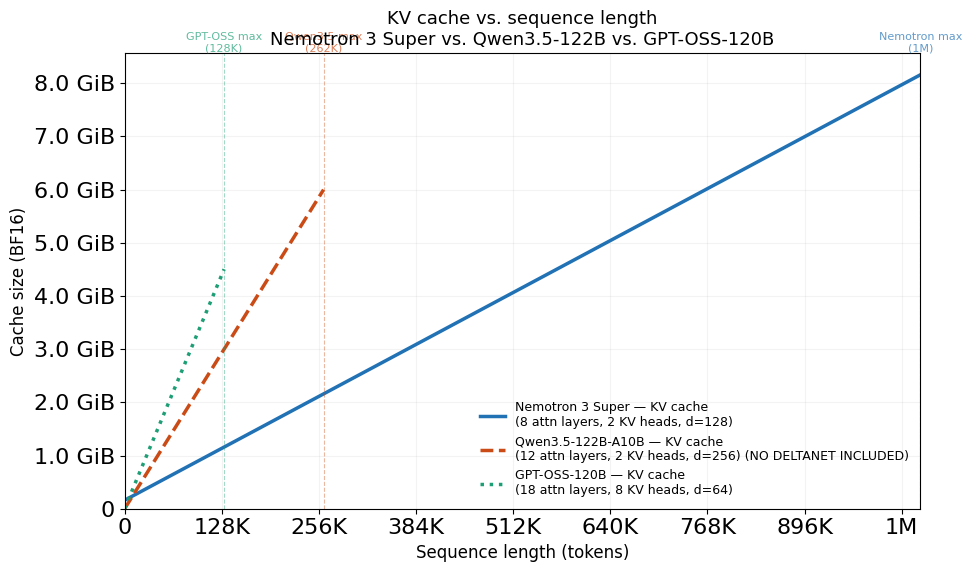


Key values at max context:
  Nemotron KV @ 1M tokens:   8.00 GiB (BF16)
  Qwen3.5  KV @ 262K tokens: 6.00 GiB (BF16)
  GPT-OSS  KV @ 128K tokens: 4.50 GiB (BF16)
  Nemotron Mamba state (fixed): 163 MiB


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Model parameters ──────────────────────────────────────────────────────────
# Nemotron 3 Super 120B-A12B (from config.json)
NEMOTRON_ATTN_LAYERS   = 8
NEMOTRON_KV_HEADS      = 2
NEMOTRON_HEAD_DIM      = 128
NEMOTRON_MAX_CTX       = 1_048_576  # 1M tokens

# Mamba fixed state (float32 SSM + BF16 conv, 40 layers)
MAMBA_LAYERS           = 40
SSM_STATE_ELEMENTS     = 128 * 64 * 128       # mamba_num_heads × mamba_head_dim × ssm_state_size
CONV_STATE_ELEMENTS    = (128*64 + 2*8*128) * 4  # conv_dim × conv_kernel
MAMBA_FIXED_BYTES      = (SSM_STATE_ELEMENTS * 4     # float32
                        + CONV_STATE_ELEMENTS * 2)   # BF16
MAMBA_FIXED_BYTES_ALL  = MAMBA_LAYERS * MAMBA_FIXED_BYTES

# Qwen3.5-122B-A10B (25% of layers are full attention, 75% Gated DeltaNet)
QWEN_ATTN_LAYERS       = 12   # 25% of ~48 total layers
QWEN_KV_HEADS          = 2
QWEN_HEAD_DIM          = 256
QWEN_MAX_CTX           = 262_144

# GPT-OSS-120B (36 layers, alternating full/sliding → 18 full attention)
# Sliding-window layers bounded at 128 tokens — negligible; omitted here
GPTOSS_ATTN_LAYERS     = 18
GPTOSS_KV_HEADS        = 8
GPTOSS_HEAD_DIM        = 64
GPTOSS_MAX_CTX         = 131_072
GPTOSS_SLIDING_LAYERS  = 18
GPTOSS_SLIDING_WINDOW  = 128  # tokens


BYTES_PER_ELEMENT_BF16 = 2  # BF16 for fair architectural comparison

# ── KV cache bytes per token (K + V, all attention layers) ────────────────────
def kv_bytes_per_token(attn_layers, kv_heads, head_dim):
    return attn_layers * kv_heads * head_dim * 2 * BYTES_PER_ELEMENT_BF16

def gptoss_total_bytes(N):
    full_kv    = GPTOSS_ATTN_LAYERS   * GPTOSS_KV_HEADS * GPTOSS_HEAD_DIM * 2 * BYTES_PER_ELEMENT_BF16 * N
    sliding_kv = GPTOSS_SLIDING_LAYERS * GPTOSS_KV_HEADS * GPTOSS_HEAD_DIM * 2 * BYTES_PER_ELEMENT_BF16 * min(N, GPTOSS_SLIDING_WINDOW)
    return full_kv + sliding_kv


nemotron_bpt = kv_bytes_per_token(NEMOTRON_ATTN_LAYERS, NEMOTRON_KV_HEADS, NEMOTRON_HEAD_DIM)
qwen_bpt     = kv_bytes_per_token(QWEN_ATTN_LAYERS,     QWEN_KV_HEADS,     QWEN_HEAD_DIM)
gptoss_bpt   = kv_bytes_per_token(GPTOSS_ATTN_LAYERS,   GPTOSS_KV_HEADS,   GPTOSS_HEAD_DIM)

GiB = 1024**3

# ── Sequence length arrays (one per model, up to its max context) ─────────────
N_nemotron = np.linspace(0, NEMOTRON_MAX_CTX, 2000)
N_qwen     = np.linspace(0, QWEN_MAX_CTX,     2000)
N_gptoss   = np.linspace(0, GPTOSS_MAX_CTX,   2000)

nemotron_kv_gib  = nemotron_bpt * N_nemotron / GiB
qwen_kv_gib      = qwen_bpt     * N_qwen     / GiB
gptoss_kv_gib    = np.array([gptoss_total_bytes(n) / GiB for n in N_gptoss])
mamba_fixed_gib  = MAMBA_FIXED_BYTES_ALL / GiB  # ~0.159 GiB

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Nemotron KV cache
ax.plot(N_nemotron / 1e3, nemotron_kv_gib + mamba_fixed_gib,
        color='#2171b5', linewidth=2.5, label='Nemotron 3 Super — KV cache\n(8 attn layers, 2 KV heads, d=128)')

# Nemotron Mamba fixed state — shaded band from 0 to mamba_fixed_gib
# ax.fill_between(N_nemotron / 1e3, 0, mamba_fixed_gib,
#                 color='#2171b5', alpha=0.12,
#                 label=f'Nemotron 3 Super — Mamba state (fixed, {mamba_fixed_gib*1024:.0f} MiB)')
# ax.axhline(mamba_fixed_gib, color='#2171b5', linewidth=0.8, linestyle='--', alpha=0.4)

# Qwen3.5 KV cache
ax.plot(N_qwen / 1e3, qwen_kv_gib,
        color='#cb4b16', linewidth=2.5, linestyle='--',
        label='Qwen3.5-122B-A10B — KV cache\n(12 attn layers, 2 KV heads, d=256) (NO DELTANET INCLUDED)')

# GPT-OSS-120B KV cache
ax.plot(N_gptoss / 1e3, gptoss_kv_gib,
        color='#1D9E75', linewidth=2.5, linestyle=':',
        label='GPT-OSS-120B — KV cache\n(18 attn layers, 8 KV heads, d=64)')

# Vertical markers at each model's max context
for max_ctx, color, label in [
    (GPTOSS_MAX_CTX,   '#1D9E75', 'GPT-OSS max\n(128K)'),
    (QWEN_MAX_CTX,     '#cb4b16', 'Qwen3.5 max\n(262K)'),
    (NEMOTRON_MAX_CTX, '#2171b5', 'Nemotron max\n(1M)'),
]:
    ax.axvline(max_ctx / 1e3, color=color, linewidth=0.8, linestyle='--', alpha=0.4)
    ax.text(max_ctx / 1e3, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 8,
            label, color=color, fontsize=8, ha='center', va='bottom', alpha=0.7)

# ── Formatting ────────────────────────────────────────────────────────────────
def gib_formatter(x, pos):
    if x == 0:
        return '0'
    if x < 1:
        return f'{x*1024:.0f} MiB'
    return f'{x:.1f} GiB'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(gib_formatter))

def ktok_formatter(x, pos):
    if x == 0:
        return '0'
    if x >= 1000:
        return f'{x/1000:.0f}M'
    return f'{int(x)}K'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(ktok_formatter))
ax.xaxis.set_major_locator(ticker.MultipleLocator(128))

ax.set_xlabel('Sequence length (tokens)', fontsize=12)
ax.set_ylabel('Cache size (BF16)', fontsize=12)
ax.set_title('KV cache vs. sequence length\nNemotron 3 Super vs. Qwen3.5-122B vs. GPT-OSS-120B',
             fontsize=13)
ax.legend(loc='lower right', fontsize=9, framealpha=0)
#ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlim(0, NEMOTRON_MAX_CTX / 1e3)
ax.set_ylim(0)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('/Users/glock/Desktop/kv_cache_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nKey values at max context:")
print(f"  Nemotron KV @ 1M tokens:   {nemotron_bpt * NEMOTRON_MAX_CTX / GiB:.2f} GiB (BF16)")
print(f"  Qwen3.5  KV @ 262K tokens: {qwen_bpt     * QWEN_MAX_CTX     / GiB:.2f} GiB (BF16)")
print(f"  GPT-OSS  KV @ 128K tokens: {gptoss_bpt   * GPTOSS_MAX_CTX   / GiB:.2f} GiB (BF16)")
print(f"  Nemotron Mamba state (fixed): {mamba_fixed_gib*1024:.0f} MiB")

In [2]:
# Break-even analysis
# Nemotron total cache = nemotron_bpt * N + MAMBA_FIXED_BYTES_ALL
# Competitor total cache = competitor_bpt * N
# Break-even: N = MAMBA_FIXED_BYTES_ALL / (competitor_bpt - nemotron_bpt)

def break_even_tokens(competitor_bpt, nemotron_bpt, mamba_fixed_bytes):
    delta = competitor_bpt - nemotron_bpt
    if delta <= 0:
        return None  # Nemotron never cheaper per token — no break-even
    return mamba_fixed_bytes / delta

be_qwen   = break_even_tokens(qwen_bpt,   nemotron_bpt, MAMBA_FIXED_BYTES_ALL)
#be_gptoss = break_even_tokens(gptoss_bpt, nemotron_bpt, MAMBA_FIXED_BYTES_ALL)

gptoss_bpt_slope = GPTOSS_ATTN_LAYERS * GPTOSS_KV_HEADS * GPTOSS_HEAD_DIM * 2 * BYTES_PER_ELEMENT_BF16

sliding_constant = (GPTOSS_SLIDING_LAYERS * GPTOSS_KV_HEADS * GPTOSS_HEAD_DIM 
                    * 2 * BYTES_PER_ELEMENT_BF16 * GPTOSS_SLIDING_WINDOW)

# Break-even (for N >> 128, sliding term is constant):
# (nemotron_bpt * N + MAMBA_FIXED_BYTES_ALL) = (gptoss_bpt_slope * N + sliding_constant)
# N = (MAMBA_FIXED_BYTES_ALL - sliding_constant) / (gptoss_bpt_slope - nemotron_bpt)

be_gptoss_corrected = (MAMBA_FIXED_BYTES_ALL - sliding_constant) / (gptoss_bpt_slope - nemotron_bpt)

print("Break-even sequence lengths:")
print(f"  vs Qwen3.5-122B:  {be_qwen:,.0f} tokens  ({be_qwen/1024:.1f}K)")
print(f"  vs GPT-OSS-120B:  {be_gptoss_corrected:,.0f} tokens  ({be_gptoss_corrected/1024:.1f}K)")
print()
print("Below the break-even, Qwen/GPT-OSS have smaller total cache (Nemotron's")
print("fixed Mamba state dominates). Above it, Nemotron wins as KV savings compound.")

Break-even sequence lengths:
  vs Qwen3.5-122B:  10,440 tokens  (10.2K)
  vs GPT-OSS-120B:  5,801 tokens  (5.7K)

Below the break-even, Qwen/GPT-OSS have smaller total cache (Nemotron's
fixed Mamba state dominates). Above it, Nemotron wins as KV savings compound.


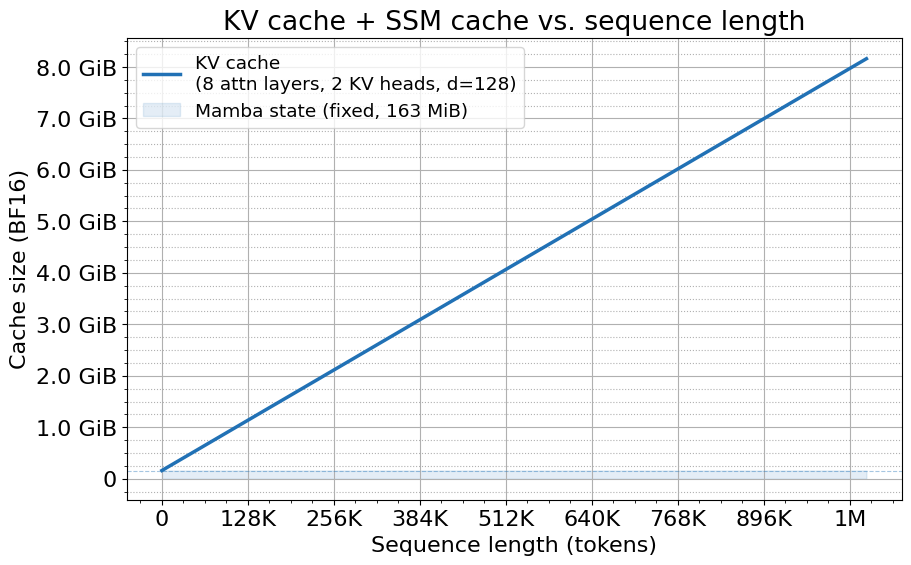

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

# Nemotron KV cache
ax.plot(N_nemotron / 1e3, nemotron_kv_gib + mamba_fixed_gib,
        color='#2171b5', linewidth=2.5, label='KV cache\n(8 attn layers, 2 KV heads, d=128)')

# Nemotron Mamba fixed state — shaded band from 0 to mamba_fixed_gib
ax.fill_between(N_nemotron / 1e3, 0, mamba_fixed_gib,
                color='#2171b5', alpha=0.12,
                label=f'Mamba state (fixed, {mamba_fixed_gib*1024:.0f} MiB)')
ax.axhline(mamba_fixed_gib, color='#2171b5', linewidth=0.8, linestyle='--', alpha=0.4)

ax.grid(True, which='major')
ax.grid(True, axis='y', which='minor', linestyle=":")
ax.set_xlabel('Sequence length (tokens)')
ax.set_ylabel('Cache size (BF16)')
ax.set_title('KV cache + SSM cache vs. sequence length')
ax.legend(fontsize='small')

ax.xaxis.set_major_formatter(ticker.FuncFormatter(ktok_formatter))
ax.xaxis.set_major_locator(ticker.MultipleLocator(128))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(32))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(.25))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(gib_formatter))